# Importing Libraries

In [5]:
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Importing Dataset

In [6]:
! gdown 11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw  # combined_model_dataset.csv

Downloading...
From: https://drive.google.com/uc?id=11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw
To: /content/combined_model_dataset.csv
100% 22.0M/22.0M [00:00<00:00, 97.3MB/s]


In [7]:
df = pd.read_csv('/content/combined_model_dataset.csv')
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('\nLabel distribution:')
print(df['label'].value_counts())
df.head()

Shape: (78954, 2)
Columns: ['text', 'label']

Label distribution:
label
0    40177
1    38777
Name: count, dtype: int64


,text,label
0,"this is politicians' strategy\n\n""Action throu...",0
1,He has underlings to do tjat for him,0
2,"Judge on separation of immigrant families: ""if...",0
3,To the republican nra(Nazi's Razing America)th...,0
4,Somebody musta complained.,0


# Data Preparation

In [8]:
# Sampling to keep Apriori computation manageable
# Stratified sample to preserve class balance
np.random.seed(42)

toxic     = df[df['label'] == 1].sample(n=5000, random_state=42)
non_toxic = df[df['label'] == 0].sample(n=5000, random_state=42)

df_sample = pd.concat([toxic, non_toxic], ignore_index=True)
print('Sampled shape:', df_sample.shape)
print('Label distribution:')
print(df_sample['label'].value_counts())

Sampled shape: (10000, 2)
Label distribution:
label
1    5000
0    5000
Name: count, dtype: int64


In [9]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join(text.split())
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

df_sample['tokens'] = df_sample['text'].apply(preprocess_text)

print('Sample tokenized text:')
for i in range(3):
    print(f'  [{df_sample["label"].iloc[i]}] {df_sample["tokens"].iloc[i][:10]}')

Sample tokenized text:
  [1] ['right', 'huh', 'sure', 'believe', 'costs', 'rail', 'hits', 'billion', 'dollar', 'mark']
  [1] ['europes', 'panic', 'migration', 'terrorism', 'big', 'opportunity', 'africa']
  [1] ['hey', 'adn', 'enough', 'trump', 'coverage', 'realize', 'generates', 'lots', 'eyeballs', 'stoop']


In [10]:
# Split into toxic and non-toxic transaction lists
toxic_transactions     = df_sample[df_sample['label'] == 1]['tokens'].tolist()
non_toxic_transactions = df_sample[df_sample['label'] == 0]['tokens'].tolist()

print('Toxic transactions     :', len(toxic_transactions))
print('Non-toxic transactions :', len(non_toxic_transactions))

Toxic transactions     : 5000
Non-toxic transactions : 5000


In [11]:
# Convert to one-hot encoded format using TransactionEncoder
te_toxic = TransactionEncoder()
toxic_encoded = te_toxic.fit_transform(toxic_transactions)
df_toxic = pd.DataFrame(toxic_encoded, columns=te_toxic.columns_)

te_non_toxic = TransactionEncoder()
non_toxic_encoded = te_non_toxic.fit_transform(non_toxic_transactions)
df_non_toxic = pd.DataFrame(non_toxic_encoded, columns=te_non_toxic.columns_)

print('Toxic one-hot shape     :', df_toxic.shape)
print('Non-toxic one-hot shape :', df_non_toxic.shape)

Toxic one-hot shape     : (5000, 18438)
Non-toxic one-hot shape : (5000, 19823)


# Why Apriori?

**1. Discovering Hidden Word Associations**  
Unlike classification models that predict labels, Apriori reveals which words frequently co-occur in toxic comments. This helps us understand the language patterns behind toxicity — e.g., certain insults or slurs tend to appear together.

**2. Comparing Toxic vs Non-Toxic Language**  
By running Apriori separately on toxic and non-toxic subsets, we can identify word combinations that are unique to toxic content. This provides interpretable insights that complement our classification models.

**3. Well-Suited for Transactional Data**  
Each comment can be treated as a "transaction" and each word as an "item". Apriori efficiently prunes the search space using the downward closure property — if a word combination is infrequent, all its supersets are also infrequent.

**4. Actionable Evaluation Metrics**  
Apriori produces rules evaluated by Support (how common), Confidence (how reliable), and Lift (how surprising) — giving a multi-dimensional view of word associations.

# Model Assumptions

| Assumption | How We Address It |
|---|---|
| Items are categorical (present or absent) | Text is tokenized into words; each word is either present or absent in a comment |
| Transactions are independent | Each comment is independently authored and sampled |
| Minimum support threshold must be set | Tested multiple thresholds (0.01–0.10) and selected 0.01 based on the number of meaningful itemsets |
| Frequent subsets of frequent itemsets also frequent (downward closure) | This is inherent to Apriori and requires no special handling |
| Word order does not matter | Apriori treats items as sets — acceptable since we focus on co-occurrence, not sequence |
| Vocabulary size affects runtime | Stopword removal and minimum word length (>2 chars) reduce vocabulary to a manageable size |

# Hyperparameter Tuning — Finding Optimal min_support

In [12]:
support_values = [0.01, 0.02, 0.03, 0.05, 0.07, 0.10]
toxic_counts     = []
non_toxic_counts = []

for s in support_values:
    fi_toxic     = apriori(df_toxic, min_support=s, use_colnames=True)
    fi_non_toxic = apriori(df_non_toxic, min_support=s, use_colnames=True)
    toxic_counts.append(len(fi_toxic))
    non_toxic_counts.append(len(fi_non_toxic))
    print(f'min_support={s:.2f} | Toxic itemsets: {len(fi_toxic):>5} | Non-toxic itemsets: {len(fi_non_toxic):>5}')

min_support=0.01 | Toxic itemsets:   494 | Non-toxic itemsets:   454
min_support=0.02 | Toxic itemsets:   159 | Non-toxic itemsets:   147
min_support=0.03 | Toxic itemsets:    58 | Non-toxic itemsets:    53
min_support=0.05 | Toxic itemsets:    20 | Non-toxic itemsets:    22
min_support=0.07 | Toxic itemsets:     8 | Non-toxic itemsets:     8
min_support=0.10 | Toxic itemsets:     6 | Non-toxic itemsets:     4


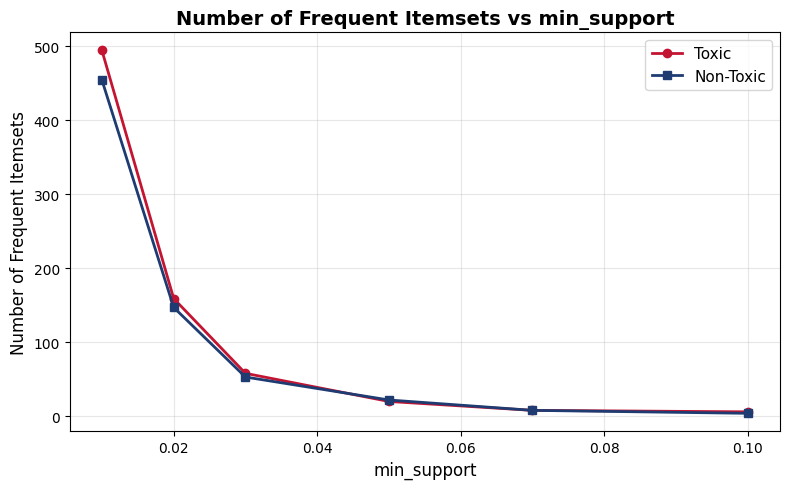

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(support_values, toxic_counts, 'o-', color='#c31432', linewidth=2, label='Toxic')
ax.plot(support_values, non_toxic_counts, 's-', color='#1e3c72', linewidth=2, label='Non-Toxic')
ax.set_title('Number of Frequent Itemsets vs min_support', fontsize=14, fontweight='bold')
ax.set_xlabel('min_support', fontsize=12)
ax.set_ylabel('Number of Frequent Itemsets', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Mining Frequent Itemsets

In [18]:
# Using min_support=0.01 — balances between too many trivial patterns and too few results
MIN_SUPPORT = 0.01

freq_toxic = apriori(df_toxic, min_support=MIN_SUPPORT, use_colnames=True, max_len=4)
freq_non_toxic = apriori(df_non_toxic, min_support=MIN_SUPPORT, use_colnames=True, max_len=4)

# Add itemset length
freq_toxic['length'] = freq_toxic['itemsets'].apply(len)
freq_non_toxic['length'] = freq_non_toxic['itemsets'].apply(len)

print('Toxic frequent itemsets     :', len(freq_toxic))
print('Non-toxic frequent itemsets :', len(freq_non_toxic))

Toxic frequent itemsets     : 494
Non-toxic frequent itemsets : 454


In [19]:
# Distribution of itemset sizes
print('Toxic itemsets by length:')
print(freq_toxic['length'].value_counts().sort_index())
print()
print('Non-toxic itemsets by length:')
print(freq_non_toxic['length'].value_counts().sort_index())

Toxic itemsets by length:
length
1    385
2    109
Name: count, dtype: int64

Non-toxic itemsets by length:
length
1    370
2     84
Name: count, dtype: int64


In [20]:
# Top 15 frequent itemsets (2+ words) in toxic comments
top_toxic = freq_toxic[freq_toxic['length'] >= 2].sort_values('support', ascending=False).head(15)
print('Top 15 Frequent Word Combinations in Toxic Comments:')
for _, row in top_toxic.iterrows():
    words = ', '.join(sorted(row['itemsets']))
    print(f'  Support: {row["support"]:.4f}  |  {{{words}}}')

Top 15 Frequent Word Combinations in Toxic Comments:
  Support: 0.0296  |  {like, people}
  Support: 0.0270  |  {like, trump}
  Support: 0.0250  |  {dont, like}
  Support: 0.0244  |  {like, would}
  Support: 0.0238  |  {get, people}
  Support: 0.0238  |  {dont, people}
  Support: 0.0232  |  {people, would}
  Support: 0.0228  |  {like, one}
  Support: 0.0212  |  {one, would}
  Support: 0.0212  |  {people, trump}
  Support: 0.0210  |  {get, like}
  Support: 0.0202  |  {one, people}
  Support: 0.0200  |  {trump, would}
  Support: 0.0188  |  {president, trump}
  Support: 0.0180  |  {dont, know}


In [21]:
# Top 15 frequent itemsets (2+ words) in non-toxic comments
top_non_toxic = freq_non_toxic[freq_non_toxic['length'] >= 2].sort_values('support', ascending=False).head(15)
print('Top 15 Frequent Word Combinations in Non-Toxic Comments:')
for _, row in top_non_toxic.iterrows():
    words = ', '.join(sorted(row['itemsets']))
    print(f'  Support: {row["support"]:.4f}  |  {{{words}}}')

Top 15 Frequent Word Combinations in Non-Toxic Comments:
  Support: 0.0236  |  {like, would}
  Support: 0.0234  |  {dont, people}
  Support: 0.0226  |  {like, people}
  Support: 0.0226  |  {people, would}
  Support: 0.0220  |  {one, would}
  Support: 0.0216  |  {one, people}
  Support: 0.0212  |  {like, one}
  Support: 0.0208  |  {dont, like}
  Support: 0.0198  |  {dont, know}
  Support: 0.0194  |  {dont, think}
  Support: 0.0192  |  {dont, would}
  Support: 0.0188  |  {many, people}
  Support: 0.0168  |  {get, one}
  Support: 0.0168  |  {dont, one}
  Support: 0.0168  |  {people, think}


# Generating Association Rules

In [44]:
# Generate rules for toxic comments
rules_toxic = association_rules(freq_toxic, metric='confidence', min_threshold=0.2, num_itemsets=len(freq_toxic))
rules_toxic = rules_toxic.sort_values('lift', ascending=False)

print(f'Total association rules (toxic): {len(rules_toxic)}')
print()
print('Top 10 Rules by Lift (Toxic Comments):')
for i, row in rules_toxic.head(10).iterrows():
    ant = ', '.join(sorted(row['antecedents']))
    con = ', '.join(sorted(row['consequents']))
    print(f'  {{{ant}}} => {{{con}}}')
    print(f'    Support: {row["support"]:.4f}  |  Confidence: {row["confidence"]:.4f}  |  Lift: {row["lift"]:.4f}')

Total association rules (toxic): 68

Top 10 Rules by Lift (Toxic Comments):
  {black} => {white}
    Support: 0.0104  |  Confidence: 0.3490  |  Lift: 6.5111
  {donald} => {trump}
    Support: 0.0124  |  Confidence: 0.6139  |  Lift: 4.6294
  {trumps} => {trump}
    Support: 0.0106  |  Confidence: 0.4953  |  Lift: 3.7355
  {president} => {trump}
    Support: 0.0188  |  Confidence: 0.4821  |  Lift: 3.6354
  {obama} => {trump}
    Support: 0.0122  |  Confidence: 0.4729  |  Lift: 3.5661
  {hes} => {trump}
    Support: 0.0124  |  Confidence: 0.4306  |  Lift: 3.2470
  {know} => {dont}
    Support: 0.0180  |  Confidence: 0.2941  |  Lift: 2.7284
  {want} => {dont}
    Support: 0.0138  |  Confidence: 0.2760  |  Lift: 2.5603
  {think} => {dont}
    Support: 0.0176  |  Confidence: 0.2543  |  Lift: 2.3593
  {cant} => {get}
    Support: 0.0104  |  Confidence: 0.2311  |  Lift: 2.3535


In [43]:
# Generate rules for non-toxic comments
rules_non_toxic = association_rules(freq_non_toxic, metric='confidence', min_threshold=0.2, num_itemsets=len(freq_non_toxic))
rules_non_toxic = rules_non_toxic.sort_values('lift', ascending=False)

print(f'Total association rules (non-toxic): {len(rules_non_toxic)}')
print()
print('Top 10 Rules by Lift (Non-Toxic Comments):')
for i, row in rules_non_toxic.head(10).iterrows():
    ant = ', '.join(sorted(row['antecedents']))
    con = ', '.join(sorted(row['consequents']))
    print(f'  {{{ant}}} => {{{con}}}')
    print(f'    Support: {row["support"]:.4f}  |  Confidence: {row["confidence"]:.4f}  |  Lift: {row["lift"]:.4f}')

Total association rules (non-toxic): 46

Top 10 Rules by Lift (Non-Toxic Comments):
  {president} => {trump}
    Support: 0.0112  |  Confidence: 0.4444  |  Lift: 5.8634
  {dont} => {know}
    Support: 0.0198  |  Confidence: 0.2012  |  Lift: 3.1738
  {know} => {dont}
    Support: 0.0198  |  Confidence: 0.3123  |  Lift: 3.1738
  {think} => {dont}
    Support: 0.0194  |  Confidence: 0.2764  |  Lift: 2.8085
  {another} => {one}
    Support: 0.0102  |  Confidence: 0.3054  |  Lift: 2.6836
  {back} => {get}
    Support: 0.0118  |  Confidence: 0.2323  |  Lift: 2.6396
  {want} => {dont}
    Support: 0.0118  |  Confidence: 0.2565  |  Lift: 2.6069
  {many} => {people}
    Support: 0.0188  |  Confidence: 0.2937  |  Lift: 2.4520
  {money} => {people}
    Support: 0.0116  |  Confidence: 0.2857  |  Lift: 2.3849
  {could} => {would}
    Support: 0.0164  |  Confidence: 0.2971  |  Lift: 2.3655


# Model Evaluation

In [45]:
print('===== Toxic Comments =====')
print('Total frequent itemsets :', len(freq_toxic))
print('Total association rules :', len(rules_toxic))
if len(rules_toxic) > 0:
    print('Avg Support             :', round(rules_toxic['support'].mean(), 4))
    print('Avg Confidence          :', round(rules_toxic['confidence'].mean(), 4))
    print('Avg Lift                :', round(rules_toxic['lift'].mean(), 4))
    print('Max Lift                :', round(rules_toxic['lift'].max(), 4))

print()

print('===== Non-Toxic Comments =====')
print('Total frequent itemsets :', len(freq_non_toxic))
print('Total association rules :', len(rules_non_toxic))
if len(rules_non_toxic) > 0:
    print('Avg Support             :', round(rules_non_toxic['support'].mean(), 4))
    print('Avg Confidence          :', round(rules_non_toxic['confidence'].mean(), 4))
    print('Avg Lift                :', round(rules_non_toxic['lift'].mean(), 4))
    print('Max Lift                :', round(rules_non_toxic['lift'].max(), 4))

===== Toxic Comments =====
Total frequent itemsets : 494
Total association rules : 68
Avg Support             : 0.0145
Avg Confidence          : 0.2551
Avg Lift                : 2.0356
Max Lift                : 6.5111

===== Non-Toxic Comments =====
Total frequent itemsets : 454
Total association rules : 46
Avg Support             : 0.0141
Avg Confidence          : 0.2397
Avg Lift                : 2.1199
Max Lift                : 5.8634


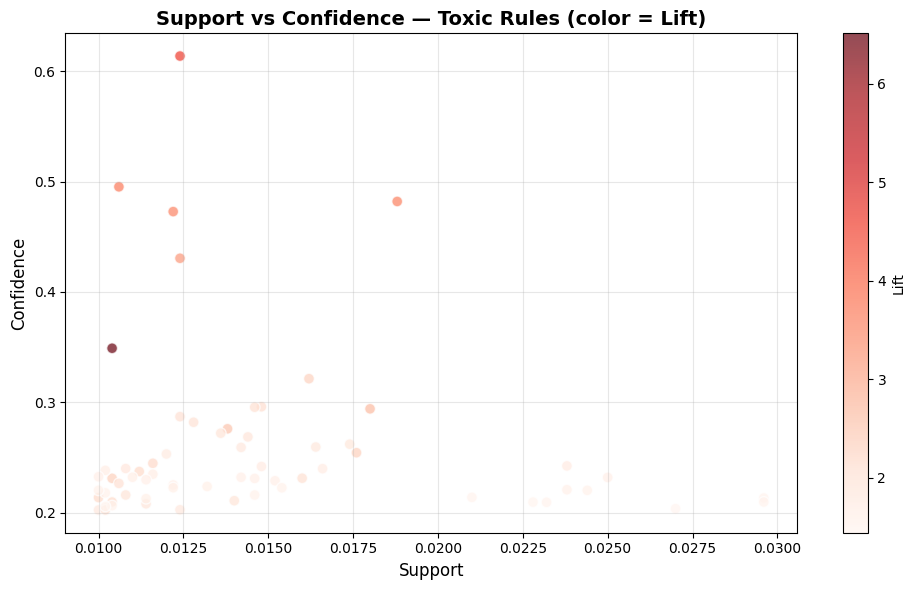

In [46]:
# Support vs Confidence scatter plot — Toxic rules
if len(rules_toxic) > 0:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        rules_toxic['support'], rules_toxic['confidence'],
        c=rules_toxic['lift'], cmap='Reds', alpha=0.7,
        edgecolors='white', s=60
    )
    plt.colorbar(scatter, label='Lift')
    plt.title('Support vs Confidence — Toxic Rules (color = Lift)', fontsize=14, fontweight='bold')
    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

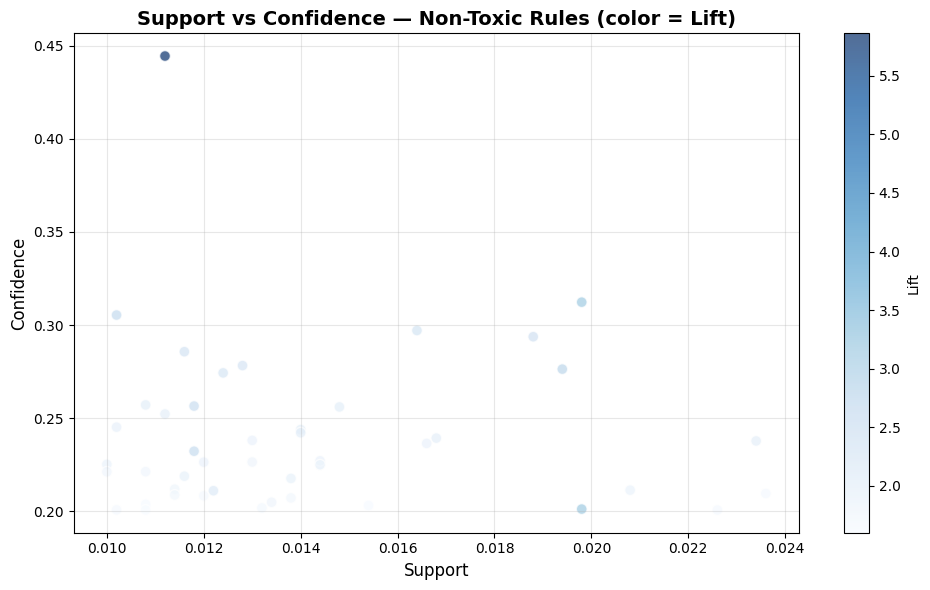

In [47]:
# Support vs Confidence scatter plot — Non-Toxic rules
if len(rules_non_toxic) > 0:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        rules_non_toxic['support'], rules_non_toxic['confidence'],
        c=rules_non_toxic['lift'], cmap='Blues', alpha=0.7,
        edgecolors='white', s=60
    )
    plt.colorbar(scatter, label='Lift')
    plt.title('Support vs Confidence — Non-Toxic Rules (color = Lift)', fontsize=14, fontweight='bold')
    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

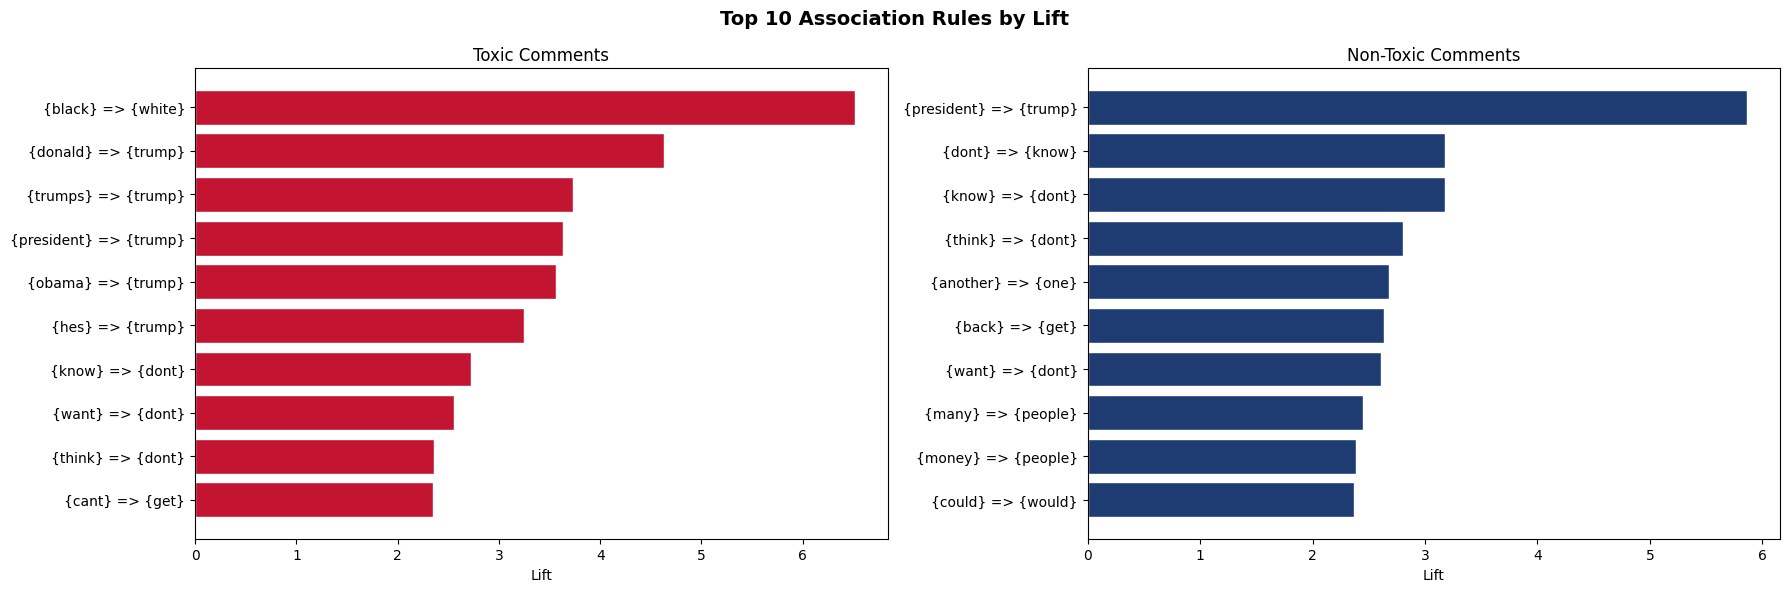

In [48]:
# Top 10 rules by lift — side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Top 10 Association Rules by Lift', fontsize=14, fontweight='bold')

if len(rules_toxic) > 0:
    top_t = rules_toxic.head(10).copy()
    top_t['rule'] = top_t.apply(
        lambda r: '{' + ', '.join(sorted(r['antecedents'])) + '} => {' + ', '.join(sorted(r['consequents'])) + '}', axis=1
    )
    axes[0].barh(top_t['rule'], top_t['lift'], color='#c31432', edgecolor='white')
    axes[0].set_title('Toxic Comments')
    axes[0].set_xlabel('Lift')
    axes[0].invert_yaxis()

if len(rules_non_toxic) > 0:
    top_nt = rules_non_toxic.head(10).copy()
    top_nt['rule'] = top_nt.apply(
        lambda r: '{' + ', '.join(sorted(r['antecedents'])) + '} => {' + ', '.join(sorted(r['consequents'])) + '}', axis=1
    )
    axes[1].barh(top_nt['rule'], top_nt['lift'], color='#1e3c72', edgecolor='white')
    axes[1].set_title('Non-Toxic Comments')
    axes[1].set_xlabel('Lift')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Challenges Faced & Solutions

| Challenge | Solution |
|---|---|
| Raw text cannot be fed to Apriori directly | Preprocessed text into tokenized word lists, then used TransactionEncoder for one-hot encoding |
| Large vocabulary makes Apriori slow | Removed stopwords and short words (<=2 chars) to reduce vocabulary size significantly |
| Full dataset (78K rows) is too large for Apriori | Sampled 5,000 toxic + 5,000 non-toxic comments (balanced stratified sample) |
| Choosing min_support threshold | Tested multiple thresholds (0.01–0.10) and selected 0.01 as a balance between quantity and quality of itemsets |
| Common words dominating frequent itemsets | Stopword removal and minimum word length filter helped surface more meaningful word associations |
| Comparing patterns across classes | Ran Apriori separately on toxic and non-toxic subsets to directly contrast word associations |

# Before and After Data Transformation Snapshots

In [49]:
# BEFORE — raw text
print('BEFORE — Raw Text:')
print(df_sample[['text', 'label']].head(5).to_string(index=False))
print('\nShape:', df_sample.shape)
print('Dtype:', df_sample['text'].dtype)

BEFORE — Raw Text:
                                                                                                                                                                                                                                                                                                                                                                                                                                                             text  label
                                               Right, uh huh, sure we "believe" you, and so what will you do when the costs for rail hits the $10 billion dollar mark and then exceed it?  Are you gonna eat your "hat," or dance in the rain like a fool, or some other piece of nonsense? Common sense is not somthing that has had any "traction" when used in conjunction with the "HART Bored or the City admin," that much should be apparent, even to you.      1
                                                                   

In [50]:
# AFTER — tokenized word lists (transactions)
print('AFTER — Tokenized Transactions:')
for i in range(5):
    label = df_sample['label'].iloc[i]
    tokens = df_sample['tokens'].iloc[i][:8]
    print(f'  [label={label}] {tokens}')

print(f'\nTotal transactions: {len(df_sample)}')

AFTER — Tokenized Transactions:
  [label=1] ['right', 'huh', 'sure', 'believe', 'costs', 'rail', 'hits', 'billion']
  [label=1] ['europes', 'panic', 'migration', 'terrorism', 'big', 'opportunity', 'africa']
  [label=1] ['hey', 'adn', 'enough', 'trump', 'coverage', 'realize', 'generates', 'lots']
  [label=1] ['connecting', 'momstobe', 'doctors', 'online', 'boost', 'autism', 'rates', 'ignorant']
  [label=1] ['hey', 'one', 'five', 'cowards', 'public', 'shaming', 'please', 'tell']

Total transactions: 10000


In [51]:
# AFTER — one-hot encoded transaction matrix (what Apriori receives)
print('AFTER — One-Hot Encoded (Toxic subset, first 5 rows x 10 columns):')
print(df_toxic.iloc[:5, :10])
print(f'\nFull shape: {df_toxic.shape}')
print(f'Dtype: {df_toxic.dtypes[0]}')

AFTER — One-Hot Encoded (Toxic subset, first 5 rows x 10 columns):
     aaa  aaarrrrggghhhh   aala  aaron  abacus  abandon  abandoned  \
0  False           False  False  False   False    False      False   
1  False           False  False  False   False    False      False   
2  False           False  False  False   False    False      False   
3  False           False  False  False   False    False      False   
4  False           False  False  False   False    False      False   

   abandoning  abandons  abatement  
0       False     False      False  
1       False     False      False  
2       False     False      False  
3       False     False      False  
4       False     False      False  

Full shape: (5000, 18438)
Dtype: bool


In [52]:
# Summary: transformation pipeline
summary = pd.DataFrame({
    'Stage': [
        'Raw Text',
        'After Preprocessing & Tokenization',
        'After TransactionEncoder (One-Hot)'
    ],
    'Format': [
        'String',
        'List of words per comment',
        'Boolean matrix (True/False per word)'
    ],
    'Typical Shape': [
        '(N,)',
        '(N, variable words per comment)',
        '(N, vocab_size)'
    ],
    'Usable by Apriori?': ['No', 'No', 'Yes']
})
print(summary.to_string(index=False))

                             Stage                               Format                   Typical Shape Usable by Apriori?
                          Raw Text                               String                            (N,)                 No
After Preprocessing & Tokenization            List of words per comment (N, variable words per comment)                 No
After TransactionEncoder (One-Hot) Boolean matrix (True/False per word)                 (N, vocab_size)                Yes
